
MAXIMUM LIKELIHOOD ANALYSIS (PD, PA)  [table lookup version]

Reading simulation probability tables...
  P0 table   = energy_pixel_probability_tables/per_energy_pixel_probabilities_all.csv
  P100 table = energy_pa_phi_pixel_probability_tables/p100_true_lookup.npz

Table summary:
  table energies = [ 15.  20.  30.  40.  50.  60.  80. 100.]
  n_energy       = 8
  n_PA bins      = 361
  n_phi bins     = 36
  n_pixels       = 1024

Reading ON/OFF event files...
Energy cut applied: 15.0-60.0 keV

Exposure summary:
  total_exp_on  = 48822.91 s
  total_exp_off = 15371.35 s

Data summary after cuts:
  nOn  = 43,766
  nOff = 4,589
  tOn  = 48822.9 s
  tOff = 15371.3 s

Fractions:
  scale = tOn/tOff = 3.1762
  nS ≈ 29,190.3
  nB ≈ 14,575.7
  xiS = 0.666963
  xiB = 0.333037

Background table built from OFF events.

Subsample disabled: using ALL ON events for grid scan.

Running coarse grid scan...
Coarse best-fit:
  PD ≈ 1.50%
  PA ≈ 140.00 deg

Running fine grid scan...
  PD range: 0.00% to 4.5

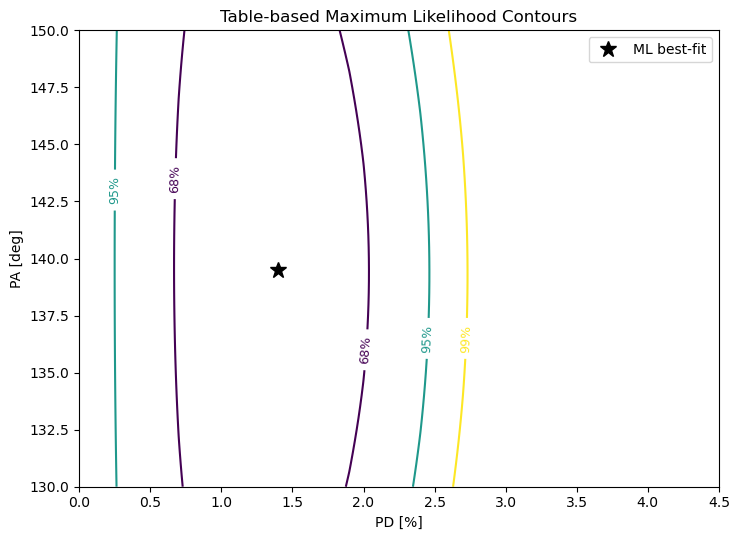

In [1]:
# -*- coding: utf-8 -*-
"""
Maximum likelihood (PD, PA) using simulation lookup tables

workflow as previous ML notebook:

1) Read ON/OFF event files
2) Apply the energy cut
3) Build event-level phi from Q/U
4) Build event-level pixel_id from detector COLUMN and Z_LAYER
5) Estimate source/background fractions xiS and xiB from ON/OFF counts + exposures
6) Read simulation probability tables:
      P100(E, phi_bin, pixel)  = 100% polarized source lookup table
      P0(E, pixel)             = unpolarized source lookup table
7) Build P_BG(E, pixel) from OFF events
8) Scan PD and PA with maximum likelihood
9) Make a contour plot

Main change from the old notebook:

Old likelihood:
    p_i = 1 + xiS * PD * mu_i * cos(2*(phi_i - PA))

New likelihood:
    p_i = xiB * P_BG(E_i, pixel_i)
        + xiS * [ PD * P100(E_i, phi_i - PA, pixel_i)
                  + (1 - PD) * P0(E_i, pixel_i) ]

Here, PA affects the lookup through:
    phi_relative_i = phi_i - PA

For this first version, phi_relative is mapped to the nearest simulated phi bin.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from pathlib import Path

print("\n" + "="*76)
print("MAXIMUM LIKELIHOOD ANALYSIS (PD, PA)  [table lookup version]")
print("="*76)

# =========================
# FILES (edit if needed)
# =========================

on_files = [
    '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pon_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010003/event/xl2024010003_pon_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010004/event/xl2024010004_pon_cl.evt.gz',
]

off_files = [
    '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pof_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010003/event/xl2024010003_pof_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010004/event/xl2024010004_pof_cl.evt.gz',
]

# Simulation tables generated by simulation5 polarized.ipynb.
# P100 is the true 100% polarized joint table: P(E, PA, phi, pixel).
# P0 is the per-energy unpolarized pixel table.
TABLE_DIR = Path('energy_pixel_probability_tables')
TRUE_P100_TABLE_DIR = Path('energy_pa_phi_pixel_probability_tables')

P0_TABLE_PATH = TABLE_DIR / 'per_energy_pixel_probabilities_all.csv'
P100_TABLE_PATH = TRUE_P100_TABLE_DIR / 'p100_true_lookup.npz'


# USER SETTINGS
EVENTS_HDU = 1

# EVT column names. If your FITS file uses different names, edit them here.
COL_Q = 'Q'
COL_U = 'U'
COL_PI = 'PI'
COL_W = 'WEIGHT'
COL_COLUMN = 'COLUMN'     # detector global column, expected 1..32
COL_ROW = 'Z_LAYER'       # detector z-layer / row, expected 1..32

# Energy cut. PI is assumed to be in 0.1 keV units
ENERGY_MIN_KEV = 15.0
ENERGY_MAX_KEV = 60.0
PI_min = int(ENERGY_MIN_KEV / 0.1)
PI_max = int(ENERGY_MAX_KEV / 0.1)

# Grid scan settings. 
PD_MIN, PD_MAX = 0.0, 0.30
PA_MIN, PA_MAX = 0.0, np.pi

PD_STEP_COARSE = 0.005
PA_STEP_COARSE_DEG = 2.0

PD_HALF_WINDOW_FINE = 0.03
PA_HALF_WINDOW_FINE_DEG = 10.0
PD_STEP_FINE = 0.001
PA_STEP_FINE_DEG = 0.5

# Optional speed controls.
USE_SUBSAMPLE = False
N_SAMPLE = 20000
RANDOM_SEED = 12345
USE_WEIGHTS = False

# Numerical safety. never allow log(0).
EPS = 1e-12

# Detector table sizes.
N_GLOBAL_COLUMNS = 32
N_Z_LAYERS = 32
N_PIXELS = N_GLOBAL_COLUMNS * N_Z_LAYERS

# =========================
# BASIC HELPERS

def get_total_exposure(file_list):
    """Sum EVENTS header EXPOSURE over all files."""
    total_exp = 0.0
    for fp in file_list:
        with fits.open(fp) as hdul:
            hdr = hdul[EVENTS_HDU].header
            total_exp += float(hdr.get('EXPOSURE', 0.0))
    return total_exp


def read_evt_arrays(file_list):
    """
    Read the event arrays needed for the table likelihood.

    We need:
      Q, U       -> event phi angle
      PI         -> event energy
      COLUMN     -> detector global column
      Z_LAYER    -> detector z layer / row
      WEIGHT     -> optional event weights
    """
    Q_all = []
    U_all = []
    pi_all = []
    column_all = []
    row_all = []
    weight_all = []

    for fp in file_list:
        with fits.open(fp) as hdul:
            tab = hdul[EVENTS_HDU].data

            Q_all.append(np.asarray(tab[COL_Q], dtype=float))
            U_all.append(np.asarray(tab[COL_U], dtype=float))
            pi_all.append(np.asarray(tab[COL_PI], dtype=float))
            column_all.append(np.asarray(tab[COL_COLUMN], dtype=int))
            row_all.append(np.asarray(tab[COL_ROW], dtype=int))
            weight_all.append(np.asarray(tab[COL_W], dtype=float))

    Q_all = np.concatenate(Q_all) if Q_all else np.array([], dtype=float)
    U_all = np.concatenate(U_all) if U_all else np.array([], dtype=float)
    pi_all = np.concatenate(pi_all) if pi_all else np.array([], dtype=float)
    column_all = np.concatenate(column_all) if column_all else np.array([], dtype=int)
    row_all = np.concatenate(row_all) if row_all else np.array([], dtype=int)
    weight_all = np.concatenate(weight_all) if weight_all else np.array([], dtype=float)

    return Q_all, U_all, pi_all, column_all, row_all, weight_all


def build_phi(Q, U):
    """
    Build event azimuth angle from Q/U.

    This follows your old notebook:
        phi = 0.5 * atan2(U, Q)
    and maps it to [0, pi).

    PA is also scanned over [0, pi), because linear polarization has 180-degree symmetry.
    """
    phi = 0.5 * np.arctan2(U, Q)
    phi = np.mod(phi, np.pi)
    return phi


def build_pixel_id(column, row):
    """
    Convert detector COLUMN and Z_LAYER into the same pixel_id convention used by simulation.

    Simulation convention:
        pixel_id = global_column_index * 32 + z_layer_index

    FITS convention assumed here:
        COLUMN  = 1..32
        Z_LAYER = 1..32

    Therefore:
        global_column_index = COLUMN - 1
        z_layer_index       = Z_LAYER - 1
    """
    global_column_index = column - 1
    z_layer_index = row - 1
    pixel_id = global_column_index * N_Z_LAYERS + z_layer_index
    return pixel_id.astype(int)


def nearest_energy_index(event_energy_keV, table_energies):
    """
    Map each event energy to the nearest simulation energy table.

    Example:
        event energy = 23.4 keV
        table energies = [15, 20, 30, ...]
        nearest table energy = 20 or 30, whichever is closer.
    """
    event_energy_keV = np.asarray(event_energy_keV, dtype=float)
    energy_idx = np.zeros(len(event_energy_keV), dtype=int)

    for i in range(len(event_energy_keV)):
        diff = np.abs(table_energies - event_energy_keV[i])
        energy_idx[i] = int(np.argmin(diff))

    return energy_idx


def nearest_phi_index(phi_relative, phi_values):
    """Map event phi to the nearest simulated phi bin."""
    phi_relative = np.mod(phi_relative, 2.0 * np.pi)
    phi_idx = np.zeros(len(phi_relative), dtype=int)

    for i in range(len(phi_relative)):
        diff = np.abs(np.angle(np.exp(1j * (phi_values - phi_relative[i]))))
        phi_idx[i] = int(np.argmin(diff))

    return phi_idx


def nearest_pa_index(PA, pa_values):
    """Map PA in [0, pi) to the nearest true-P100 PA table bin."""
    PA = np.mod(PA, np.pi)
    diff = np.abs(np.angle(np.exp(2j * (pa_values - PA))))
    return int(np.argmin(diff))


def normalize_probability_rows(table_2d):
    """Normalize each row of a 2D table so every row sums to 1."""
    out = np.array(table_2d, dtype=float)
    for i in range(out.shape[0]):
        row_sum = out[i].sum()
        if row_sum > 0:
            out[i] = out[i] / row_sum
    return out

# =========================
# READ SIMULATION TABLES
# =========================

print("\nReading simulation probability tables...")
print(f"  P0 table   = {P0_TABLE_PATH}")
print(f"  P100 table = {P100_TABLE_PATH}")

p0_df = pd.read_csv(P0_TABLE_PATH)
p100_npz = np.load(P100_TABLE_PATH)

# Energies are shared by P0 and P100 tables.
table_energies = np.array(sorted(p0_df['energy_keV'].unique()), dtype=float)
energy_values_p100 = p100_npz['energy_values'].astype(float)
n_energy = len(table_energies)

# PA and phi bins come from the true P100 table.
pa_values_table = p100_npz['pa_values_rad'].astype(float)
phi_values_table = p100_npz['phi_values_rad'].astype(float)
n_PA = len(pa_values_table)
n_phi = len(phi_values_table)

# P0 shape: (n_energy, n_pixels)
P0_table = np.zeros((n_energy, N_PIXELS), dtype=float)

for energy_idx in range(n_energy):
    energy_keV = table_energies[energy_idx]
    sub = p0_df[p0_df['energy_keV'] == energy_keV].sort_values('pixel_id')
    P0_table[energy_idx, :] = sub['probability'].to_numpy(dtype=float)

P0_table = np.maximum(P0_table, EPS)
P0_table = normalize_probability_rows(P0_table)

# P100 shape: (n_energy, n_PA, n_phi, n_pixels)
P100_table = p100_npz['P100_true'].astype(float)
P100_table = np.maximum(P100_table, EPS)

if P100_table.shape != (n_energy, n_PA, n_phi, N_PIXELS):
    raise ValueError(f"Unexpected P100 shape: {P100_table.shape}")
if not np.allclose(table_energies, energy_values_p100):
    raise ValueError("P0 and P100 energy grids do not match.")

print("\nTable summary:")
print(f"  table energies = {table_energies}")
print(f"  n_energy       = {n_energy}")
print(f"  n_PA bins      = {n_PA}")
print(f"  n_phi bins     = {n_phi}")
print(f"  n_pixels       = {N_PIXELS}")

# =========================
# READ ON/OFF EVENTS
# =========================

print("\nReading ON/OFF event files...")

Q_on, U_on, PI_on, column_on, row_on, weight_on = read_evt_arrays(on_files)
Q_off, U_off, PI_off, column_off, row_off, weight_off = read_evt_arrays(off_files)

# Apply energy cut to every event-level array.
m_on = (PI_on >= PI_min) & (PI_on <= PI_max)
m_off = (PI_off >= PI_min) & (PI_off <= PI_max)

Q_on = Q_on[m_on]
U_on = U_on[m_on]
PI_on = PI_on[m_on]
column_on = column_on[m_on]
row_on = row_on[m_on]
weight_on = weight_on[m_on]

Q_off = Q_off[m_off]
U_off = U_off[m_off]
PI_off = PI_off[m_off]
column_off = column_off[m_off]
row_off = row_off[m_off]
weight_off = weight_off[m_off]

print(f"Energy cut applied: {ENERGY_MIN_KEV}-{ENERGY_MAX_KEV} keV")

# Keep only events with valid detector coordinates.
valid_on = (
    (column_on >= 1) & (column_on <= N_GLOBAL_COLUMNS) &
    (row_on >= 1) & (row_on <= N_Z_LAYERS)
)
valid_off = (
    (column_off >= 1) & (column_off <= N_GLOBAL_COLUMNS) &
    (row_off >= 1) & (row_off <= N_Z_LAYERS)
)

Q_on = Q_on[valid_on]
U_on = U_on[valid_on]
PI_on = PI_on[valid_on]
column_on = column_on[valid_on]
row_on = row_on[valid_on]
weight_on = weight_on[valid_on]

Q_off = Q_off[valid_off]
U_off = U_off[valid_off]
PI_off = PI_off[valid_off]
column_off = column_off[valid_off]
row_off = row_off[valid_off]
weight_off = weight_off[valid_off]

# Build event-level variables for likelihood.
phi_on = build_phi(Q_on, U_on)
phi_off = build_phi(Q_off, U_off)

energy_on_keV = PI_on * 0.1
energy_off_keV = PI_off * 0.1

energy_idx_on = nearest_energy_index(energy_on_keV, table_energies)
energy_idx_off = nearest_energy_index(energy_off_keV, table_energies)

pixel_on = build_pixel_id(column_on, row_on)
pixel_off = build_pixel_id(column_off, row_off)

# =========================
# EXPOSURE AND SOURCE/BACKGROUND FRACTIONS
# =========================

total_exp_on = get_total_exposure(on_files)
total_exp_off = get_total_exposure(off_files)

nOn = len(phi_on)
nOff = len(phi_off)
tOn = float(total_exp_on)
tOff = float(total_exp_off)

print("\nExposure summary:")
print(f"  total_exp_on  = {tOn:.2f} s")
print(f"  total_exp_off = {tOff:.2f} s")

print(f"\nData summary after cuts:")
print(f"  nOn  = {nOn:,}")
print(f"  nOff = {nOff:,}")
print(f"  tOn  = {tOn:.1f} s")
print(f"  tOff = {tOff:.1f} s")

scale = tOn / tOff if tOff > 0 else 0.0
nS = nOn - scale * nOff
nS = max(nS, 0.0)
nB = nOn - nS

xiS = np.clip(nS / nOn, 0.0, 1.0) if nOn > 0 else 0.0
xiB = 1.0 - xiS

print("\nFractions:")
print(f"  scale = tOn/tOff = {scale:.4f}")
print(f"  nS ≈ {nS:,.1f}")
print(f"  nB ≈ {nB:,.1f}")
print(f"  xiS = {xiS:.6f}")
print(f"  xiB = {xiB:.6f}")

# =========================
# BUILD BACKGROUND TABLE FROM OFF EVENTS
# =========================

# P_BG shape: (n_energy, n_pixels)
# We build it from OFF events, separately for each simulation energy bin.
# A small EPS is added so empty pixels do not cause log(0).
P_BG_table = np.zeros((n_energy, N_PIXELS), dtype=float)

for energy_idx in range(n_energy):
    mask = energy_idx_off == energy_idx
    counts = np.bincount(pixel_off[mask], minlength=N_PIXELS).astype(float)
    counts = counts + EPS
    P_BG_table[energy_idx, :] = counts / counts.sum()

print("\nBackground table built from OFF events.")

# =========================
# SUBSAMPLE FOR SPEED
# =========================

if USE_SUBSAMPLE and nOn > N_SAMPLE:
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(nOn, size=N_SAMPLE, replace=False)

    phi_used = phi_on[idx]
    energy_idx_used = energy_idx_on[idx]
    pixel_used = pixel_on[idx]
    w_used = weight_on[idx] if USE_WEIGHTS else None

    print(f"\nSubsample enabled: using {N_SAMPLE:,} / {nOn:,} ON events for grid scan.")
else:
    phi_used = phi_on
    energy_idx_used = energy_idx_on
    pixel_used = pixel_on
    w_used = weight_on if USE_WEIGHTS else None

    print("\nSubsample disabled: using ALL ON events for grid scan.")

# =========================
# TABLE-BASED LOG-LIKELIHOOD
# =========================

def loglike_PD_PA_table(phi, energy_idx, pixel, PD, PA, xiS,
                        P100_table, P0_table, P_BG_table, phi_values,
                        weights=None):
    """
    Table-based event-level log-likelihood.

    For each ON event i, the measured phi_i from Q/U is in [0, pi).
    Therefore the lookup uses both equivalent simulation directions:

        phi_i and phi_i + pi

    Then we look up:

        P100_i = P100_table[energy_idx_i, PA_bin, phi_bin_i, pixel_i]
               + P100_table[energy_idx_i, PA_bin, phi_bin_i + pi, pixel_i]
        P0_i   = P0_table[energy_idx_i, pixel_i] / (n_phi / 2)
        PBG_i  = P_BG_table[energy_idx_i, pixel_i] / (n_phi / 2)

    P100_table is generated in the simulation notebook and already includes the
    100% polarization modulation for each PA bin.

    The event probability is:

        P_model_i = xiB * PBG_i
                  + xiS * (PD * P100_i + (1 - PD) * P0_i)

    Finally:

        lnL = sum_i log(P_model_i)
    """
    xiB = 1.0 - xiS

    phi_idx = nearest_phi_index(phi, phi_values)
    phi_idx_opposite = nearest_phi_index(phi + np.pi, phi_values)
    PA_idx = nearest_pa_index(PA, pa_values_table)

    P100_i = (
        P100_table[energy_idx, PA_idx, phi_idx, pixel]
        + P100_table[energy_idx, PA_idx, phi_idx_opposite, pixel]
    )
    P0_i = P0_table[energy_idx, pixel] / (float(len(phi_values)) / 2.0)
    PBG_i = P_BG_table[energy_idx, pixel] / (float(len(phi_values)) / 2.0)

    P_model_i = xiB * PBG_i + xiS * (PD * P100_i + (1.0 - PD) * P0_i)
    P_model_i = np.maximum(P_model_i, EPS)

    if weights is None:
        return float(np.sum(np.log(P_model_i)))
    else:
        return float(np.sum(weights * np.log(P_model_i)))


def scan_grid_table(phi, energy_idx, pixel, xiS, PD_grid, PA_grid,
                    P100_table, P0_table, P_BG_table, phi_values,
                    weights=None):
    """Scan a grid of PD and PA values and return lnL[PD_index, PA_index]."""
    ll = np.empty((len(PD_grid), len(PA_grid)), dtype=float)

    for j, PA in enumerate(PA_grid):
        for i, PD in enumerate(PD_grid):
            ll[i, j] = loglike_PD_PA_table(
                phi=phi,
                energy_idx=energy_idx,
                pixel=pixel,
                PD=PD,
                PA=PA,
                xiS=xiS,
                P100_table=P100_table,
                P0_table=P0_table,
                P_BG_table=P_BG_table,
                phi_values=phi_values,
                weights=weights,
            )

    return ll

# =========================
# COARSE GRID SCAN
# =========================

PD_grid_coarse = np.arange(PD_MIN, PD_MAX + 0.5*PD_STEP_COARSE, PD_STEP_COARSE)
PA_grid_coarse = np.deg2rad(np.arange(0.0, 180.0 + 0.5*PA_STEP_COARSE_DEG, PA_STEP_COARSE_DEG))

print("\nRunning coarse grid scan...")
ll_coarse = scan_grid_table(
    phi=phi_used,
    energy_idx=energy_idx_used,
    pixel=pixel_used,
    xiS=xiS,
    PD_grid=PD_grid_coarse,
    PA_grid=PA_grid_coarse,
    P100_table=P100_table,
    P0_table=P0_table,
    P_BG_table=P_BG_table,
    phi_values=phi_values_table,
    weights=w_used,
)

imax = np.unravel_index(np.argmax(ll_coarse), ll_coarse.shape)
PD_best_coarse = PD_grid_coarse[imax[0]]
PA_best_coarse = PA_grid_coarse[imax[1]]

print("Coarse best-fit:")
print(f"  PD ≈ {PD_best_coarse*100:.2f}%")
print(f"  PA ≈ {np.degrees(PA_best_coarse):.2f} deg")

# =========================
# FINE GRID SCAN AROUND COARSE BEST FIT
# =========================

PD_lo = max(PD_MIN, PD_best_coarse - PD_HALF_WINDOW_FINE)
PD_hi = min(PD_MAX, PD_best_coarse + PD_HALF_WINDOW_FINE)

PA_center_deg = np.degrees(PA_best_coarse)
PA_lo_deg = max(0.0, PA_center_deg - PA_HALF_WINDOW_FINE_DEG)
PA_hi_deg = min(180.0, PA_center_deg + PA_HALF_WINDOW_FINE_DEG)

PD_grid_fine = np.arange(PD_lo, PD_hi + 0.5*PD_STEP_FINE, PD_STEP_FINE)
PA_grid_fine = np.deg2rad(np.arange(PA_lo_deg, PA_hi_deg + 0.5*PA_STEP_FINE_DEG, PA_STEP_FINE_DEG))

print("\nRunning fine grid scan...")
print(f"  PD range: {PD_lo*100:.2f}% to {PD_hi*100:.2f}%  step {PD_STEP_FINE*100:.2f}%")
print(f"  PA range: {PA_lo_deg:.2f} deg to {PA_hi_deg:.2f} deg  step {PA_STEP_FINE_DEG:.2f} deg")

ll_fine = scan_grid_table(
    phi=phi_used,
    energy_idx=energy_idx_used,
    pixel=pixel_used,
    xiS=xiS,
    PD_grid=PD_grid_fine,
    PA_grid=PA_grid_fine,
    P100_table=P100_table,
    P0_table=P0_table,
    P_BG_table=P_BG_table,
    phi_values=phi_values_table,
    weights=w_used,
)

imax2 = np.unravel_index(np.argmax(ll_fine), ll_fine.shape)
PD_hat = PD_grid_fine[imax2[0]]
PA_hat = PA_grid_fine[imax2[1]]
ll_max = ll_fine[imax2]

print("\nML best-fit (fine scan):")
print(f"  PD_hat = {PD_hat*100:.2f}%")
print(f"  PA_hat = {np.degrees(PA_hat):.2f} deg")
print(f"  lnL_max = {ll_max:.6e}")

# =========================
# CONTOUR PLOT
# =========================

# Wilks-style levels for two parameters.
# These are the same values you used before.
dlnL = ll_max - ll_fine
levels = [1.15, 3.00, 4.61]
labels = ['68%', '95%', '99%']

PD_mesh, PA_mesh = np.meshgrid(PD_grid_fine*100.0, np.degrees(PA_grid_fine), indexing='ij')

plt.figure(figsize=(7.5, 5.5))
CS = plt.contour(PD_mesh, PA_mesh, dlnL, levels=levels)
plt.clabel(CS, inline=True, fontsize=9, fmt=dict(zip(levels, labels)))
plt.plot(PD_hat*100.0, np.degrees(PA_hat), 'k*', markersize=12, label='ML best-fit')
plt.xlabel('PD [%]')
plt.ylabel('PA [deg]')
plt.title('Table-based Maximum Likelihood Contours')
plt.legend()
plt.tight_layout()
plt.show()
